In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
black_df = pd.read_csv('../out/black_GlobalMAD_filtered.tsv', sep='\t', header=0, index_col=0)
white_df = pd.read_csv('../out/white_GlobalMAD_filtered.tsv', sep='\t', header=0, index_col=0)

# merge expression on shared genes, then transpose to samples x genes
merged_df = pd.concat([black_df, white_df], axis=1, join='inner').T

In [14]:
black_meta_df = pd.read_csv('../out/black_filtered_metadata.tsv', sep='\t', header=0)
white_meta_df = pd.read_csv('../out/white_filtered_metadata.tsv', sep='\t', header=0)

# add race to metadata
black_meta_df['race'] = 'black'
white_meta_df['race'] = 'white'

merged_meta_df = pd.concat([black_meta_df, white_meta_df], axis=0)
# align to expr sample order for correct coloring
merged_meta_df = merged_meta_df.set_index('ID').loc[merged_df.index]

In [15]:
print(merged_df.shape, merged_meta_df.shape)

(571, 4355) (571, 10)


In [16]:
X = StandardScaler().fit_transform(merged_df)

In [ ]:
pca = PCA(n_components=3)
pcs = pca.fit_transform(X)

In [18]:
pca_df = pd.DataFrame(pcs, columns=['PC1', 'PC2', 'PC3'], index=merged_df.index)
pca_df = pca_df.join(merged_meta_df[['ClusterK4_kmeans', 'race']])

In [19]:
# variance explained (answers question 3d)
var = pca.explained_variance_ratio_[:3] * 100
print(f"PC1: {var[0]:.1f}%, PC2: {var[1]:.1f}%, PC3: {var[2]:.1f}%")

PC1: 83.9%, PC2: 5.0%, PC3: 2.8%


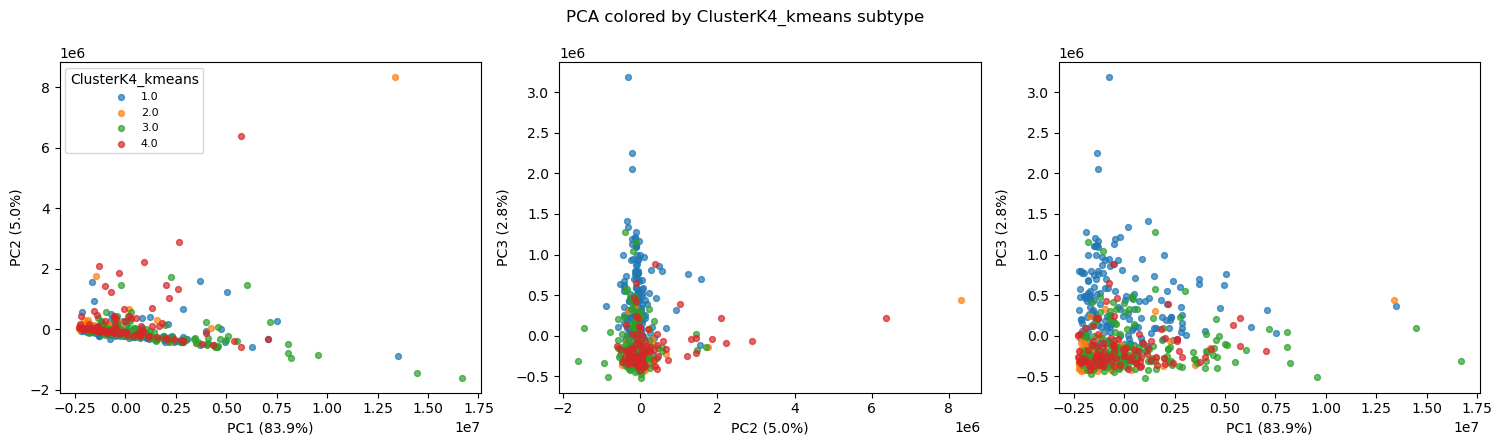

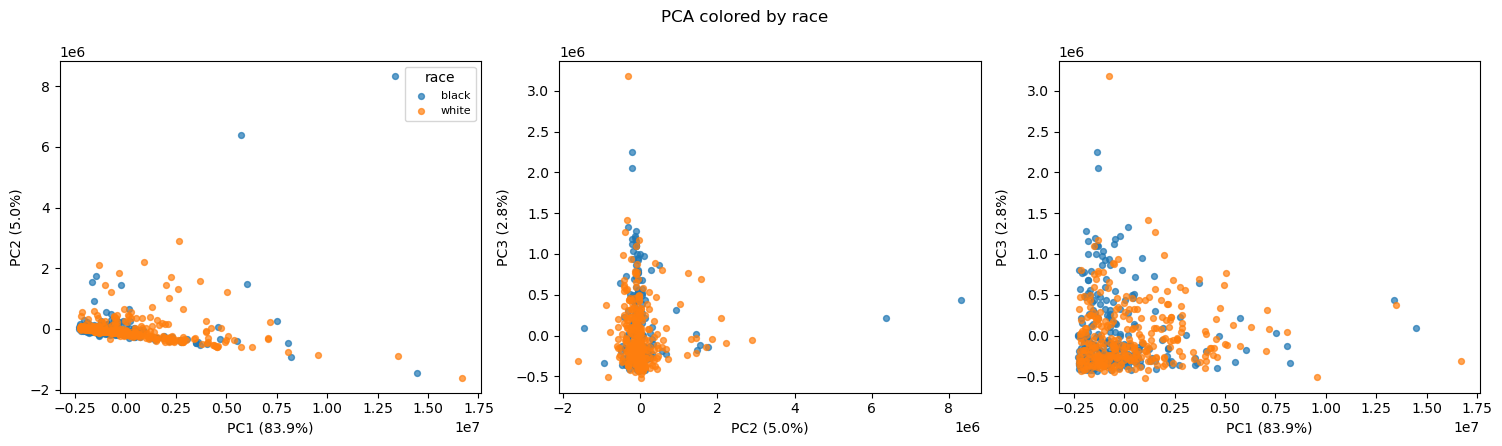

In [20]:
import matplotlib.pyplot as plt

# variance for axis labels
var = pca.explained_variance_ratio_ * 100
pc_pairs = [('PC1', 'PC2'), ('PC2', 'PC3'), ('PC1', 'PC3')]
pc_var = {'PC1': var[0], 'PC2': var[1], 'PC3': var[2]}


def plot_pca(color_col, title, cmap_discrete=True):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    groups = pca_df[color_col].astype('category')
    cats = groups.cat.categories
    colors = plt.cm.tab10(range(len(cats)))

    for ax, (x, y) in zip(axes, pc_pairs):
        for cat, c in zip(cats, colors):
            mask = groups == cat
            ax.scatter(pca_df.loc[mask, x], pca_df.loc[mask, y],
                       s=18, alpha=0.7, color=c, label=str(cat))
        ax.set_xlabel(f"{x} ({pc_var[x]:.1f}%)")
        ax.set_ylabel(f"{y} ({pc_var[y]:.1f}%)")

    axes[0].legend(title=color_col, fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_pca('ClusterK4_kmeans', 'PCA colored by ClusterK4_kmeans subtype')
plot_pca('race', 'PCA colored by race')